In [ ]:
#Irem_Dogruoglu_7061348_Lizzie_Schmitz_7056551
#References:
#1.https://matplotlib.org/stable/tutorials/introductory/pyplot.html
#2.https://github.com/gnina/gnina
#3.https://github.com/RMeli/gnina-torch
#This notebook creates outputs for docking, retraining, and analysis with GNINA-Torch.
#It loads the outputs from the main pipeline and visualizes the key metrics on the proto_test benchmark.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

#Getting the right directories for inputs and outputs. 
RESULTS_PT = Path("results")
MODEL_DIR = RESULTS_PT / "gninatorch_training"
REDO_MODEL_DIR = RESULTS_PT / "proto_test_retrained"
PLOTS_DIR = RESULTS_PT / "plots"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

#Creating loop to generate metrics for all trained model directories.
trained_model_dirs = [d for d in MODEL_DIR.iterdir() if d.is_dir()]

MODEL_DIR, REDO_MODEL_DIR, PLOTS_DIR, trained_model_dirs

(WindowsPath('results/gninatorch_training'),
 WindowsPath('results/proto_test_retrained'),
 WindowsPath('results/plots'),
 [WindowsPath('results/gninatorch_training/default2018_seed1'),
  WindowsPath('results/gninatorch_training/dense_seed1')])

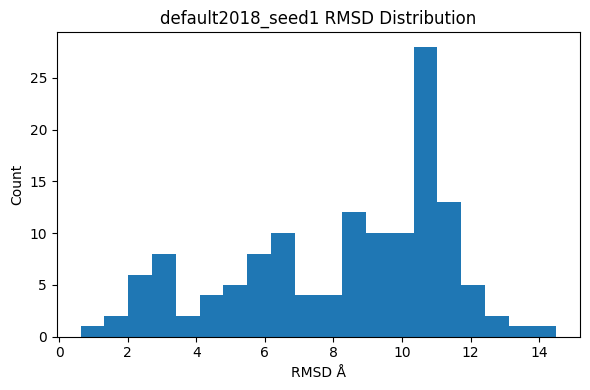

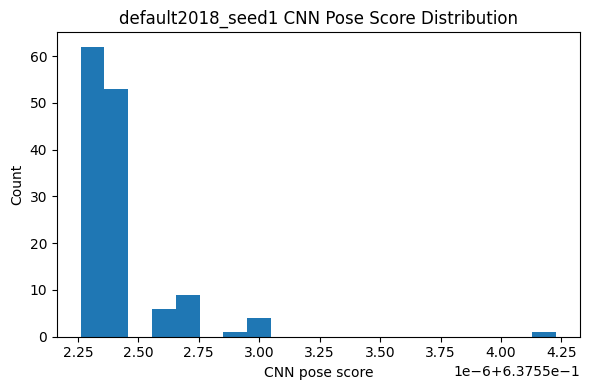

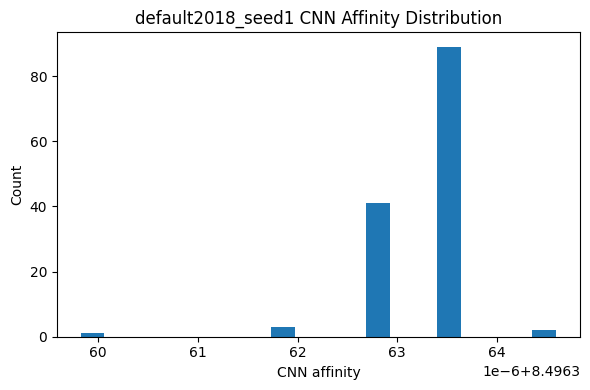

default2018_seed1: Percentage of complexes that has RMSD <= 2 Å: 2.21%


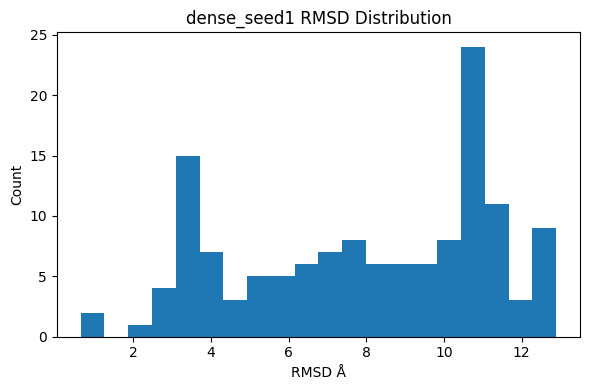

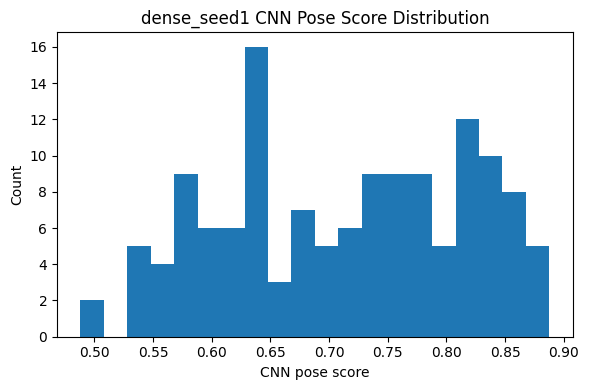

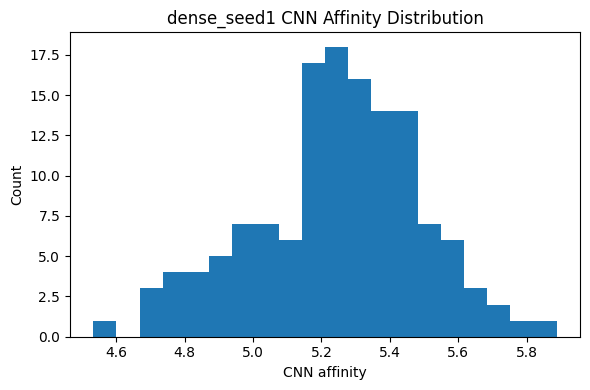

dense_seed1: Percentage of complexes that has RMSD <= 2 Å: 1.47%


In [2]:
for model_dir in trained_model_dirs:
    model_name = model_dir.name

    #Getting the metrics CSV file.
    metrics_csv = PLOTS_DIR / f"{model_name}_metrics.csv"
    metrics = pd.read_csv(metrics_csv)
    metrics.head()

    #RMSD distribution plot for retrained GNINA shows distribution of the best pose RMSD values.
    vals_rmsd = [v for v in metrics["rmsd"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_rmsd, bins=20)
    plt.title(f"{model_name} RMSD Distribution")
    plt.xlabel("RMSD Å")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Retrained GNINA CNN pose score distribution shows the best CNN pose scores on the proto_test set where higher values mean the pose is more likely to be close to the true binding mode.
    vals_ps = [v for v in metrics["best_cnn_pose_score"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_ps, bins=20)
    plt.title(f"{model_name} CNN Pose Score Distribution")
    plt.xlabel("CNN pose score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Retrained GNINA CNN affinity distribution indicates in higher values relates to stronger predicted binding affinity between ligand and receptor.
    vals_aff = [v for v in metrics["best_cnn_affinity"] if pd.notna(v)]
    plt.figure(figsize=(6,4))
    plt.hist(vals_aff, bins=20)
    plt.title(f"{model_name} CNN Affinity Distribution")
    plt.xlabel("CNN affinity")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    #Generating more detailed RMSD metrics.
    good_vals = metrics["rmsd"] <= 2.0
    good_rate = good_vals.mean()
    print(f"{model_name}: Percentage of complexes that has RMSD <= 2 Å: {good_rate:.2%}")

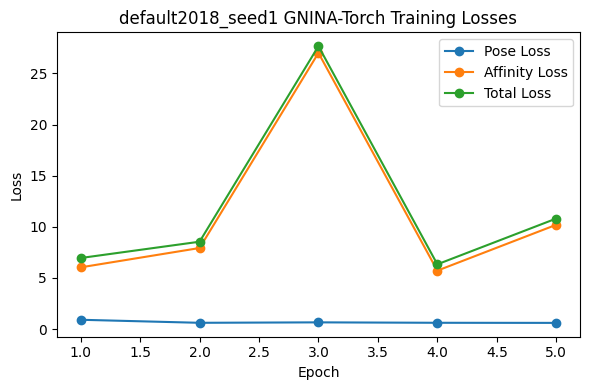

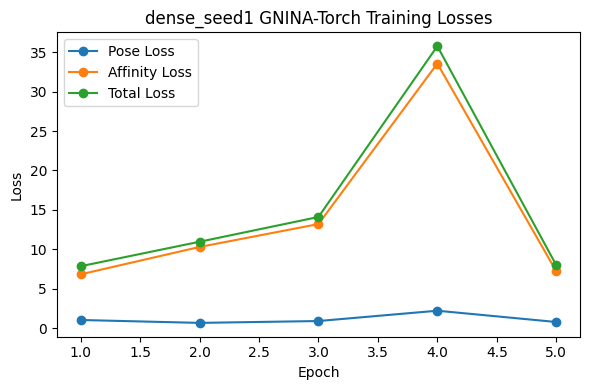

In [ ]:
#GNINA-Torch training and test pose loss plot shows how the pose loss evolves over epochs for the training and the test metrics, which enables whether the retrained model is learning and are there overfittings.
def log_metrics_train(log_fl: Path):
    metrics = {}
    if not log_fl.exists(): # error handling 
        print(f"skipping: training log not found: {log_fl}")
        return metrics

    key_map = { # dict structure
        "Accuracy": "accuracy",
        "Balanced Accuracy": "balanced_accuracy",
        "Pose Loss": "pose_loss",
        "ROC AUC": "roc_auc",
        "MAE": "mae",
        "RMSE": "rmse",
        "Affinity Loss": "affinity_loss",
        "Loss": "loss",
        "Epoch Time": "epoch_time",
        "Elapsed Time": "elapsed_time",
    }

    updated_epch = None

    with log_fl.open(errors="ignore") as f:
        for line in f:
            line = line.strip()

            # use regex expressions for flexibility while parsing metrics
            # find the training results per epoch (find headers)
            train_mtc = re.search(  
                r">>>\s*Train Results\s*-\s*Epoch\[(\d+)\]",
                line,
                re.IGNORECASE,
            )
            if train_mtc: # if there is a header line, create a new dict entry for the metrics of each training epoch
                updated_epch = int(train_mtc.group(1))
                metrics[updated_epch] = {}
                continue

            if updated_epch is None:
                continue

            metric_mtch = re.match( # for each line, find out if a metric in the dict is mentioned
                r"(.+?):\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
                line,
            )
            if metric_mtch: # get the titles (raw_key) of each line and its contents (value)
                raw_key = metric_mtch.group(1).strip()
                value = float(metric_mtch.group(2))
                if raw_key in key_map: # if the raw_key is a valid metric in the dict, put the metric and its value into the metrics dict
                    metrics[updated_epch][key_map[raw_key]] = value

    return metrics

#Iretaring over each trained model directory.
for model_dir in trained_model_dirs: 
    model_name = model_dir.name # either dense or default2018 model

    log_fl = model_dir / "training.log"
    metrics_log = log_metrics_train(log_fl)

    epochs = sorted(metrics_log.keys()) # sort by epoch dict
    pose_loss = [metrics_log[e]["pose_loss"] for e in epochs if "pose_loss" in metrics_log[e]]
    affinity_loss = [metrics_log[e]["affinity_loss"] for e in epochs if "affinity_loss" in metrics_log[e]]
    total_loss = [metrics_log[e]["loss"] for e in epochs if "loss" in metrics_log[e]]

    plt.figure(figsize=(6,4))
    if pose_loss:
        plt.plot(epochs, pose_loss, marker="o", label="Pose Loss")
    if affinity_loss:
        plt.plot(epochs, affinity_loss, marker="o", label="Affinity Loss")
    if total_loss:
        plt.plot(epochs, total_loss, marker="o", label="Total Loss")

    plt.title(f"{model_name} GNINA-Torch Training Losses")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()